# 01 · Data Quality & Sensor Analysis — NASA CMAPSS FD004

| Section | Purpose |
|---|---|
| 1. Data Quality | Missing values, duplicates, cycle continuity, lifetime distribution |
| 2. Dead Channels | Sensors with near-zero variance — no information content |
| 3. Correlation | Pairwise sensor correlation + correlation with RUL |
| 4. Operating Conditions | Why raw values cannot be used directly |
| 5. Naive Baselines | Error floor every trained model must beat |

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.float_format', '{:.3f}'.format)

RAW = Path('../data/raw')
COLS = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]
SENSOR_COLS = [f's{i}' for i in range(1, 22)]
SENSOR_NAMES = {
    's1':  'Fan inlet temperature (°R)',
    's2':  'Low-pressure compressor outlet temperature (°R)',
    's3':  'High-pressure compressor outlet temperature (°R)',
    's4':  'Low-pressure turbine outlet temperature (°R)',
    's5':  'Fan inlet pressure (psia)',
    's6':  'Bypass duct pressure (psia)',
    's7':  'High-pressure compressor outlet pressure (psia)',
    's8':  'Physical fan speed (rpm)',
    's9':  'Physical core speed (rpm)',
    's10': 'Engine pressure ratio',
    's11': 'High-pressure compressor static pressure (psia)',
    's12': 'Fuel-to-air ratio',
    's13': 'Corrected fan speed (rpm)',
    's14': 'Corrected core speed (rpm)',
    's15': 'Bypass ratio',
    's16': 'Burner fuel-air ratio',
    's17': 'Bleed air enthalpy (BTU/lb)',
    's18': 'Commanded fan speed (rpm)',
    's19': 'Commanded corrected fan speed (rpm)',
    's20': 'High-pressure turbine coolant bleed flow (lbm/s)',
    's21': 'Low-pressure turbine coolant bleed flow (lbm/s)',
}
# Compact labels for charts where full names do not fit
SENSOR_SHORT = {
    's1':  'Fan inlet temp',
    's2':  'LP compressor outlet temp',
    's3':  'HP compressor outlet temp',
    's4':  'LP turbine outlet temp',
    's5':  'Fan inlet pressure',
    's6':  'Bypass duct pressure',
    's7':  'HP compressor outlet pressure',
    's8':  'Fan speed',
    's9':  'Core speed',
    's10': 'Pressure ratio',
    's11': 'HP compressor static pressure',
    's12': 'Fuel-air ratio',
    's13': 'Corrected fan speed',
    's14': 'Corrected core speed',
    's15': 'Bypass ratio',
    's16': 'Burner fuel-air ratio',
    's17': 'Bleed air enthalpy',
    's18': 'Commanded fan speed',
    's19': 'Cmd corrected fan speed',
    's20': 'HP turbine coolant flow',
    's21': 'LP turbine coolant flow',
}

def load_raw(fd_id, split='train'):
    df = pd.read_csv(RAW / f'{split}_FD00{fd_id}.txt',
                     sep=r'\s+', header=None, names=COLS)
    df['dataset'] = f'FD00{fd_id}'
    return df

fd4 = load_raw(4, 'train')
fd2 = load_raw(2, 'train')
print(f"FD004 train: {fd4.shape} — {fd4.unit.nunique()} engines")
print(f"FD002 train: {fd2.shape} — {fd2.unit.nunique()} engines")

FD004 train: (61249, 27) — 249 engines
FD002 train: (53759, 27) — 260 engines


---
## 1 · Data Quality

=== Missing Values ===
  ✓ FD004: 0 missing values
  ✓ FD002: 0 missing values

=== Duplicate Rows ===
  ✓ FD004: 0 duplicates
  ✓ FD002: 0 duplicates

=== Cycle Continuity ===
  ✓ FD004: 0 engines with non-sequential cycles
  ✓ FD002: 0 engines with non-sequential cycles

=== Engine Lifetime ===
  FD004: min=128  max=543  mean=246.0  median=234.0  std=73.1
  FD002: min=128  max=378  mean=206.8  median=199.0  std=46.8


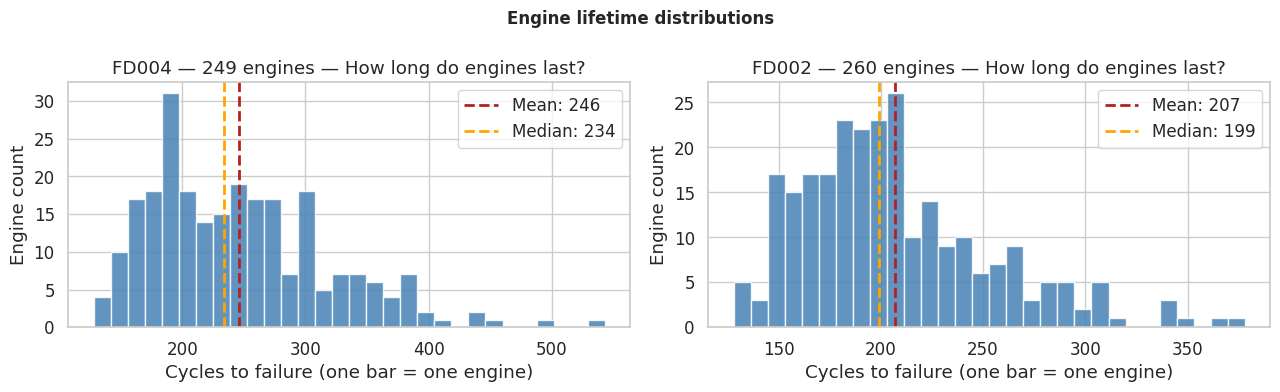

In [2]:
# Missing values
print("=== Missing Values ===")
for name, df in [('FD004', fd4), ('FD002', fd2)]:
    n = df.isnull().sum().sum()
    print(f"  {'✓' if n==0 else '✗'} {name}: {n} missing values")

# Duplicates
print("\n=== Duplicate Rows ===")
for name, df in [('FD004', fd4), ('FD002', fd2)]:
    n = df.duplicated().sum()
    print(f"  {'✓' if n==0 else '✗'} {name}: {n} duplicates")

# Cycle continuity
print("\n=== Cycle Continuity ===")
for name, df in [('FD004', fd4), ('FD002', fd2)]:
    bad = [e for e in df.unit.unique()
           if not np.array_equal(df[df.unit==e]['cycle'].values,
                                  np.arange(1, len(df[df.unit==e])+1))]
    print(f"  {'✓' if not bad else '✗'} {name}: {len(bad)} engines with non-sequential cycles")

# Lifetime distribution
print("\n=== Engine Lifetime ===")
for name, df in [('FD004', fd4), ('FD002', fd2)]:
    lt = df.groupby('unit')['cycle'].max()
    print(f"  {name}: min={lt.min()}  max={lt.max()}  mean={lt.mean():.1f}  median={lt.median():.1f}  std={lt.std():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (name, df) in zip(axes, [('FD004 — 249 engines', fd4), ('FD002 — 260 engines', fd2)]):
    lt = df.groupby('unit')['cycle'].max()
    ax.hist(lt, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(lt.mean(),   color='firebrick', ls='--', lw=2, label=f'Mean: {lt.mean():.0f}')
    ax.axvline(lt.median(), color='orange',    ls='--', lw=2, label=f'Median: {lt.median():.0f}')
    ax.set_xlabel('Cycles to failure (one bar = one engine)')
    ax.set_ylabel('Engine count')
    ax.set_title(f'{name} — How long do engines last?')
    ax.legend()
plt.suptitle('Engine lifetime distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2 · Dead Channel Identification

A sensor with near-zero standard deviation is constant across all flights and all engines. 
It carries zero information — the model cannot use it to distinguish healthy from degrading engines.

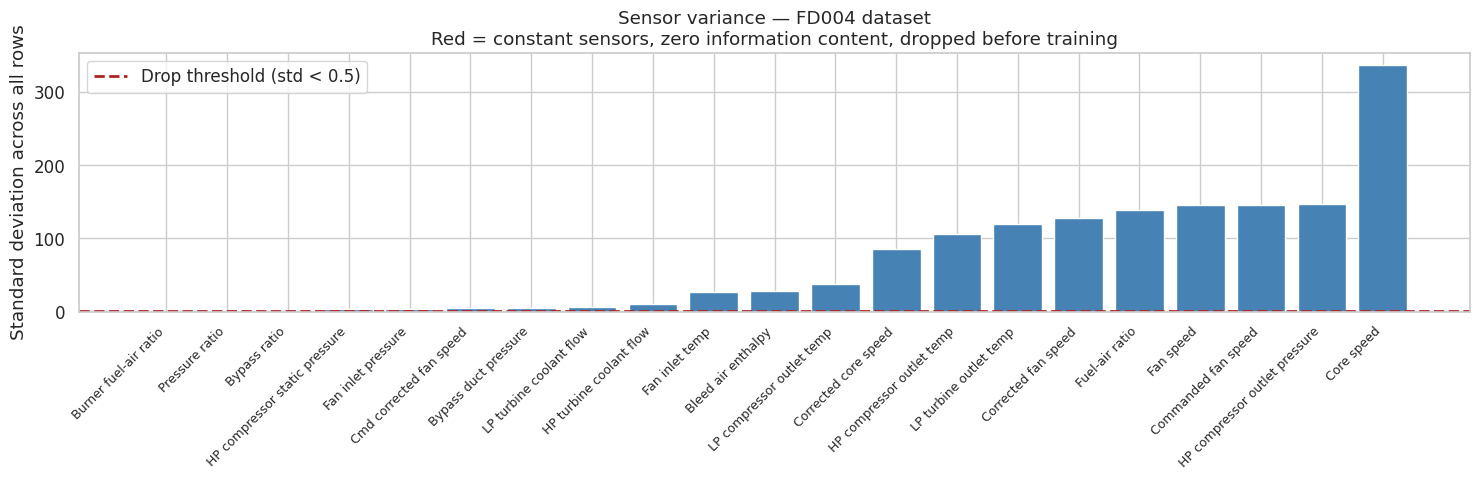

Dropped (2 sensors with zero information):
  Engine pressure ratio
  Burner fuel-air ratio

Kept (19 sensors):
  Fan inlet temperature (°R)
  Low-pressure compressor outlet temperature (°R)
  High-pressure compressor outlet temperature (°R)
  Low-pressure turbine outlet temperature (°R)
  Fan inlet pressure (psia)
  Bypass duct pressure (psia)
  High-pressure compressor outlet pressure (psia)
  Physical fan speed (rpm)
  Physical core speed (rpm)
  High-pressure compressor static pressure (psia)
  Fuel-to-air ratio
  Corrected fan speed (rpm)
  Corrected core speed (rpm)
  Bypass ratio
  Bleed air enthalpy (BTU/lb)
  Commanded fan speed (rpm)
  Commanded corrected fan speed (rpm)
  High-pressure turbine coolant bleed flow (lbm/s)
  Low-pressure turbine coolant bleed flow (lbm/s)


In [3]:
stds = fd4[SENSOR_COLS].std().sort_values()
threshold = 0.5
DEAD = [s for s in SENSOR_COLS if fd4[s].std() < threshold]
LIVE = [s for s in SENSOR_COLS if s not in DEAD]

fig, ax = plt.subplots(figsize=(15, 5))
colors = ['firebrick' if v < threshold else 'steelblue' for v in stds.to_numpy()]
ax.bar(range(len(stds)), stds.to_numpy(), color=colors)
ax.set_xticks(range(len(stds)))
ax.set_xticklabels([SENSOR_SHORT[s] for s in stds.index],
                   rotation=45, ha='right', fontsize=9)
ax.axhline(threshold, color='firebrick', ls='--', lw=2,
           label=f'Drop threshold (std < {threshold})')
ax.set_ylabel('Standard deviation across all rows')
ax.set_title('Sensor variance — FD004 dataset\n'
             'Red = constant sensors, zero information content, dropped before training')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Dropped ({len(DEAD)} sensors with zero information):")
for s in DEAD:
    print(f"  {SENSOR_NAMES[s]}")
print(f"\nKept ({len(LIVE)} sensors):")
for s in LIVE:
    print(f"  {SENSOR_NAMES[s]}")


---
## 3 · Correlation Analysis

Two questions: (1) which sensors are near-perfect duplicates of each other? (2) which sensors actually correlate with RUL — and are therefore useful for prediction?

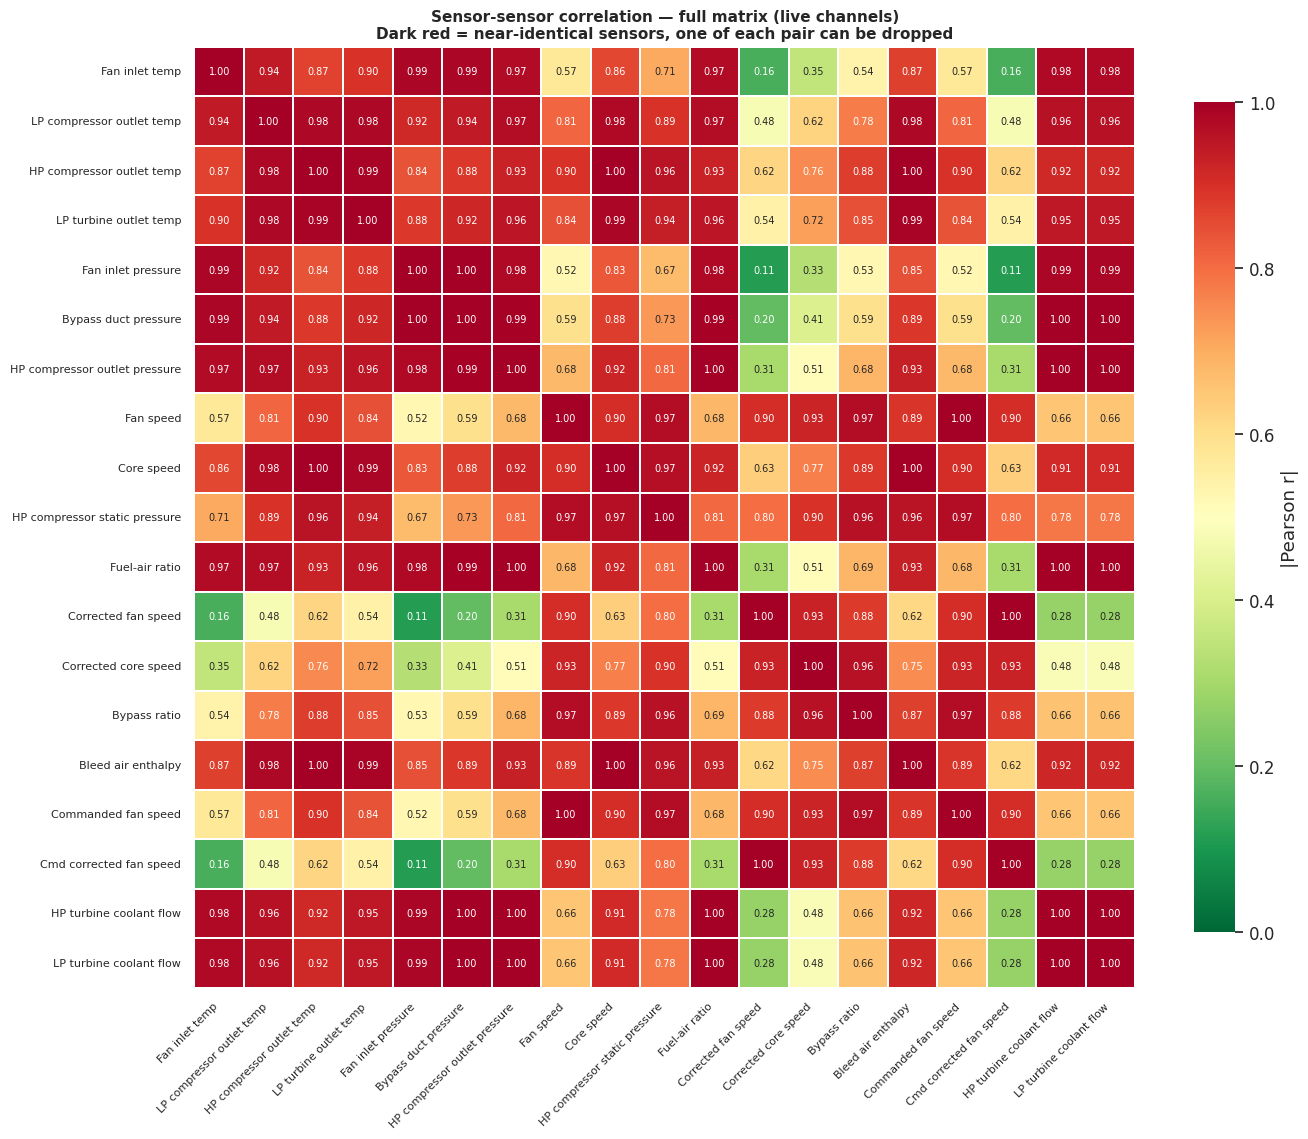

Highly correlated pairs (|r| > 0.95) — candidates for dropping:
Sensor A                        Sensor B                           |r|
------------------------------------------------------------------------
Fan inlet temp                  Fan inlet pressure              0.987
Fan inlet temp                  Bypass duct pressure            0.987
Fan inlet temp                  HP compressor outlet pressure   0.973
Fan inlet temp                  Fuel-air ratio                  0.973
Fan inlet temp                  HP turbine coolant flow         0.978
Fan inlet temp                  LP turbine coolant flow         0.978
LP compressor outlet temp       HP compressor outlet temp       0.982
LP compressor outlet temp       LP turbine outlet temp          0.981
LP compressor outlet temp       HP compressor outlet pressure   0.969
LP compressor outlet temp       Core speed                      0.978
LP compressor outlet temp       Fuel-air ratio                  0.969
LP compressor outlet t

In [4]:
fd4_tmp = fd4.copy()
fd4_tmp['rul'] = (fd4_tmp.groupby('unit')['cycle'].transform('max')
                  - fd4_tmp['cycle']).clip(upper=130)

corr = fd4[LIVE].corr().abs()

short = {s: SENSOR_SHORT[s] for s in LIVE}

# Full square — no mask
# Use short abbreviations (SENSOR_SHORT) — labels fit without overlap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr.rename(index=short, columns=short),
            annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=0, vmax=1, ax=ax,
            annot_kws={'size': 7}, linewidths=0.3,
            cbar_kws={'label': '|Pearson r|', 'shrink': 0.8},
            square=True)
ax.set_title('Sensor-sensor correlation — full matrix (live channels)\n'
             'Dark red = near-identical sensors, one of each pair can be dropped',
             fontsize=11, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Numerical table — pairs with |r| > 0.95
print("Highly correlated pairs (|r| > 0.95) — candidates for dropping:")
print(f"{'Sensor A':<30s}  {'Sensor B':<30s}  {'|r|':>6}")
print("-" * 72)
seen = set()
for i, s1 in enumerate(LIVE):
    for s2 in LIVE[i+1:]:
        v = corr.loc[s1, s2]
        if float(v) > 0.95:  # type: ignore[arg-type]
            pair = tuple(sorted([s1, s2]))
            if pair not in seen:
                seen.add(pair)
                print(f"{SENSOR_SHORT[s1]:<30s}  {SENSOR_SHORT[s2]:<30s}  {v:.3f}")


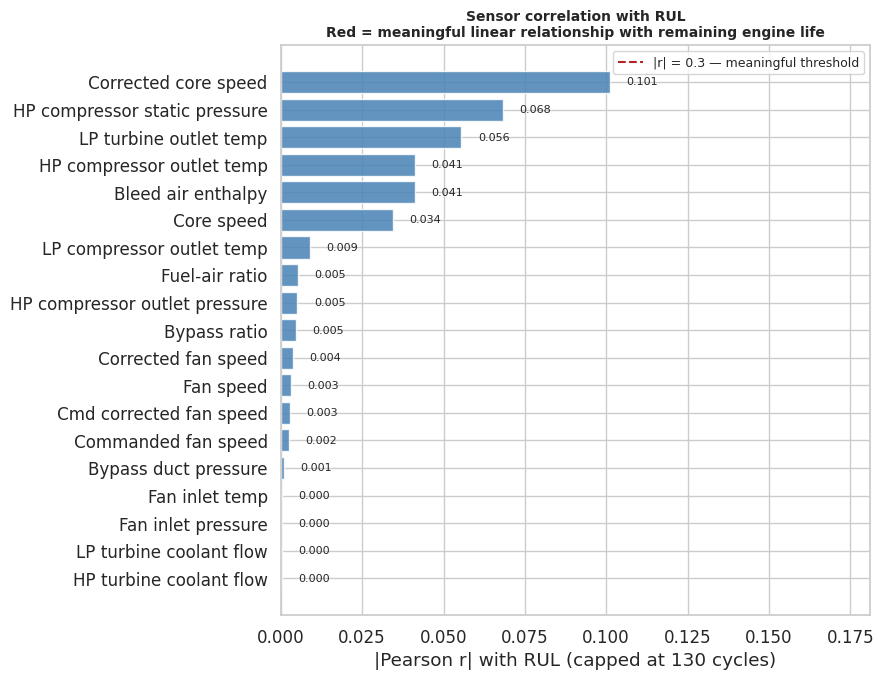


Numerical summary — sensor correlation with remaining useful life:
Sensor                                              |r| with RUL  Signal strength
---------------------------------------------------------------------------
Corrected core speed (rpm)                                 0.101  weak
High-pressure compressor static pressure (psia)            0.068  weak
Low-pressure turbine outlet temperature (°R)               0.056  weak
High-pressure compressor outlet temperature (°R)           0.041  weak
Bleed air enthalpy (BTU/lb)                                0.041  weak
Physical core speed (rpm)                                  0.034  weak
Low-pressure compressor outlet temperature (°R)            0.009  weak
Fuel-to-air ratio                                          0.005  weak
High-pressure compressor outlet pressure (psia)            0.005  weak
Bypass ratio                                               0.005  weak
Corrected fan speed (rpm)                                  0.004

In [5]:
rul_corr = (fd4_tmp[LIVE + ['rul']].corr()['rul']
            .drop('rul').abs().sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['firebrick' if v > 0.3 else 'steelblue' for v in rul_corr.to_numpy()]
bars = ax.barh([SENSOR_SHORT[s] for s in rul_corr.index], rul_corr.to_numpy(),
               color=colors, alpha=0.85)
ax.axvline(0.3, color='firebrick', ls='--', lw=1.5,
           label='|r| = 0.3 — meaningful threshold')
for bar, v in zip(bars, rul_corr.to_numpy()):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=8)
ax.set_xlabel('|Pearson r| with RUL (capped at 130 cycles)')
ax.set_title('Sensor correlation with RUL\nRed = meaningful linear relationship with remaining engine life',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, rul_corr.max() + 0.08)
plt.tight_layout()
plt.show()

print("\nNumerical summary — sensor correlation with remaining useful life:")
print(f"{'Sensor':<50s}  {'|r| with RUL':>12s}  {'Signal strength'}")
print("-" * 75)
for s in rul_corr.sort_values(ascending=False).index:
    v = rul_corr[s]
    flag = 'strong' if v > 0.5 else ('moderate' if v > 0.3 else 'weak')
    print(f"{SENSOR_NAMES[s]:<50s}  {v:>12.3f}  {flag}")


---
## 4 · Operating Conditions

Each cycle is flown at one of 6 fixed regimes defined by altitude, Mach, and throttle. 
The same sensor reads structurally different values at 0kft vs 42kft — not because the engine 
is degrading but because air density changes. Without normalisation the model learns altitude, 
not engine health.

The 6 flight conditions:

           Altitude (kft)  Mach     TRA
condition                              
0                   0.000 0.000 100.000
1                  10.000 0.250 100.000
2                  20.000 0.700 100.000
3                  25.000 0.620  60.000
4                  35.000 0.840 100.000
5                  42.000 0.840 100.000


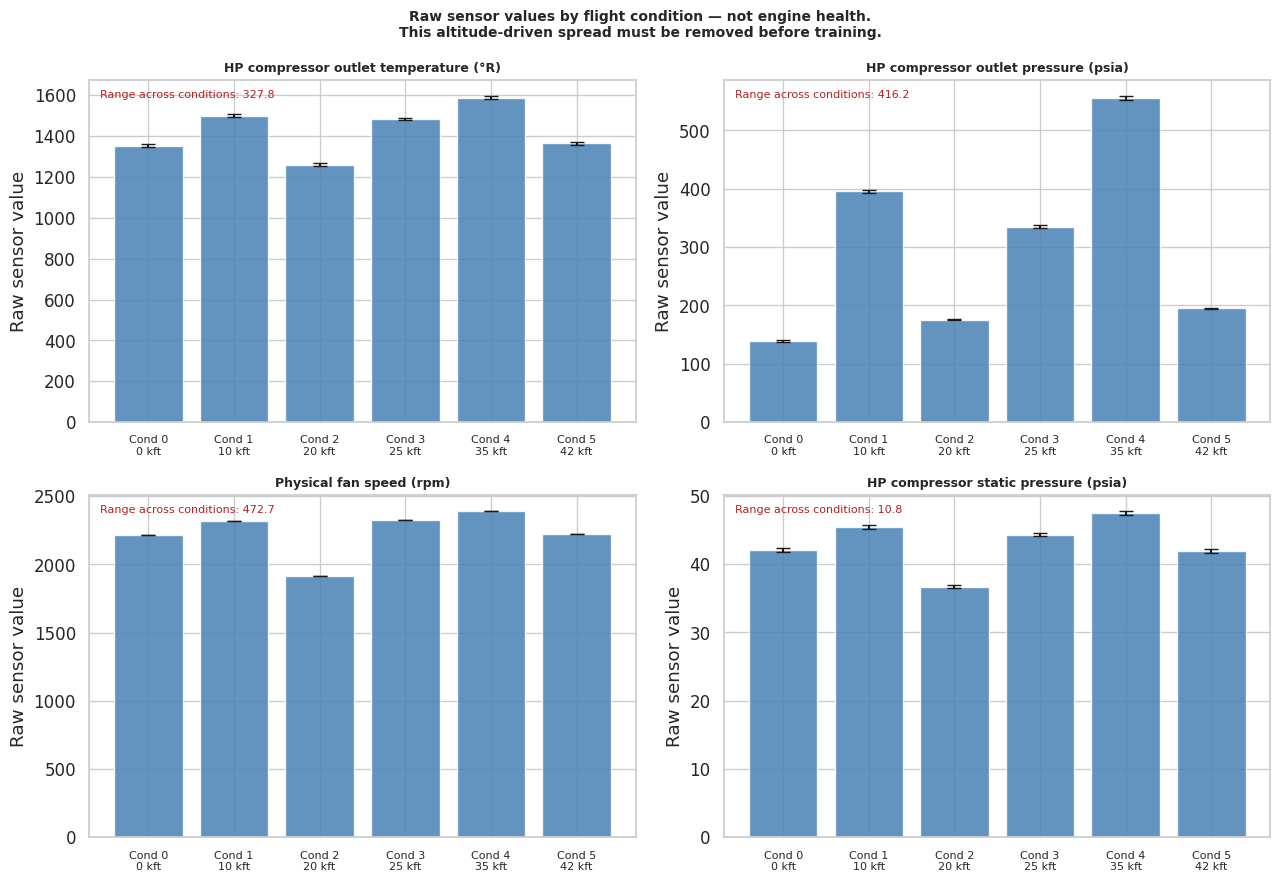

In [6]:
op_scaler = StandardScaler()
km = KMeans(n_clusters=6, random_state=42, n_init=10)
fd4['condition'] = km.fit_predict(op_scaler.fit_transform(fd4[['op1','op2','op3']]))

centres = (pd.DataFrame(op_scaler.inverse_transform(km.cluster_centers_),
                        columns=['Altitude (kft)', 'Mach', 'TRA'])
           .round(2).sort_values('Altitude (kft)').reset_index(drop=True))
centres.index.name = 'condition'
print("The 6 flight conditions:\n")
print(centres.to_string())

key_sensors = [
    ('s3',  'HP compressor outlet temperature (°R)'),
    ('s7',  'HP compressor outlet pressure (psia)'),
    ('s8',  'Physical fan speed (rpm)'),
    ('s11', 'HP compressor static pressure (psia)'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
alts = [centres.loc[c, 'Altitude (kft)'] for c in range(6)]

for ax, (s, title) in zip(axes.flatten(), key_sensors):
    by_cond = fd4.groupby('condition')[s].agg(['mean', 'std'])
    ax.bar(range(6), by_cond['mean'].values,
           yerr=by_cond['std'].values, capsize=5,
           color='steelblue', alpha=0.85, error_kw={'elinewidth': 1.5})
    ax.set_xticks(range(6))
    ax.set_xticklabels([f"Cond {c}\n{alts[c]:.0f} kft" for c in range(6)], fontsize=8)
    ax.set_ylabel('Raw sensor value')
    ax.set_title(title, fontsize=9, fontweight='bold')
    spread = by_cond['mean'].max() - by_cond['mean'].min()
    ax.text(0.02, 0.97, f'Range across conditions: {spread:.1f}',
            transform=ax.transAxes, va='top', fontsize=8, color='firebrick')

plt.suptitle('Raw sensor values by flight condition — not engine health.\n'
             'This altitude-driven spread must be removed before training.',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5 · Naive RUL Baselines

Error floor — any model using sensor data must beat these.

| Baseline | Method |
|---|---|
| Mean prediction | Always predict the mean training RUL |
| Linear on cycle count | Global linear regression using only cycle number |
| Per-engine linear | Best possible linear model — separate fit per engine |

Naive Baseline Results:

                                 MAE (cycles)  RMSE (cycles)  NASA Score
Baseline                                                                
Mean prediction                        95.400         95.400  382310.000
Linear (cycle only, global)            62.600         66.000   73717.000
Linear (cycle only, per-engine)        26.700         31.600    4454.000

Target for Phase 3 RUL model: RMSE < 31.6 cycles


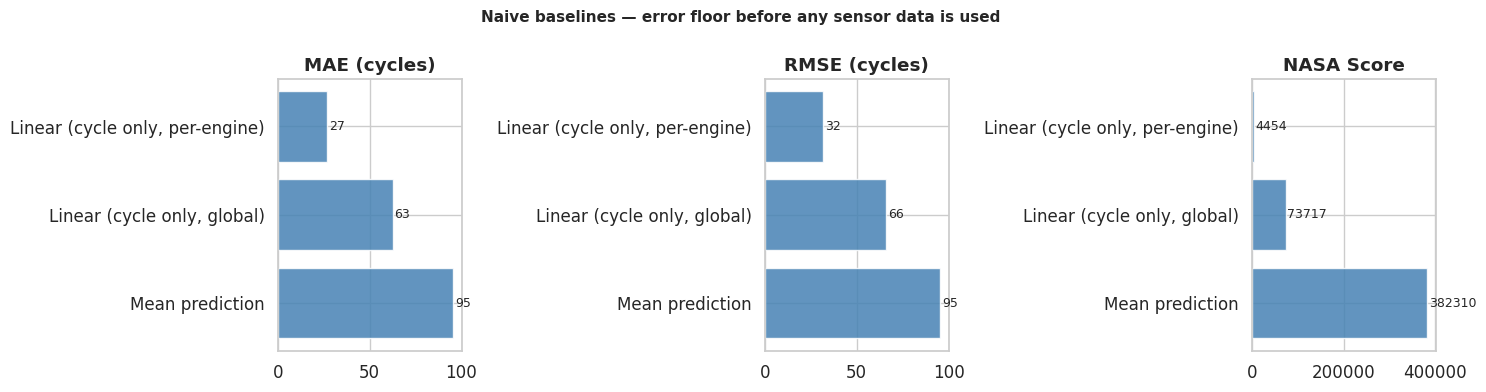

In [7]:
RUL_CAP = 130
fd4_labeled = fd4.copy()
fd4_labeled['rul'] = (fd4_labeled.groupby('unit')['cycle'].transform('max')
                      - fd4_labeled['cycle']).clip(upper=RUL_CAP)

# Test set = last observed cycle per engine (real prediction scenario)
test_rows = fd4_labeled.groupby('unit').last().reset_index()
y_test = test_rows['rul'].to_numpy()

def score_nasa(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    return float(np.sum(np.where(d < 0, np.exp(-d/10)-1, np.exp(d/13)-1)))

def row_metrics(name, y_true, y_pred):
    return {
        'Baseline': name,
        'MAE (cycles)':  round(mean_absolute_error(y_true, y_pred), 1),
        'RMSE (cycles)': round(np.sqrt(mean_squared_error(y_true, y_pred)), 1),
        'NASA Score':    round(score_nasa(y_true, y_pred), 0),
    }

results = []

# 1. Always predict mean RUL
mean_rul = fd4_labeled['rul'].mean()
results.append(row_metrics('Mean prediction',
                            y_test, np.full(len(y_test), mean_rul)))

# 2. Global linear regression on cycle only
lr = LinearRegression().fit(fd4_labeled[['cycle']], fd4_labeled['rul'])
pred_lr = lr.predict(test_rows[['cycle']]).clip(0, RUL_CAP)
results.append(row_metrics('Linear (cycle only, global)', y_test, pred_lr))

# 3. Per-engine linear — best possible linear model
per_eng = []
for _, row in test_rows.iterrows():
    eng = fd4_labeled[fd4_labeled.unit == row['unit']]
    if len(eng) < 3:
        per_eng.append(mean_rul); continue
    m = LinearRegression().fit(eng[['cycle']], eng['rul'])
    per_eng.append(float(np.clip(m.predict(np.array([[row['cycle']]]))[0], 0, RUL_CAP)))
results.append(row_metrics('Linear (cycle only, per-engine)', y_test, per_eng))

baseline_df = pd.DataFrame(results).set_index('Baseline')
print("Naive Baseline Results:\n")
print(baseline_df.to_string())
print(f"\nTarget for Phase 3 RUL model: RMSE < {baseline_df['RMSE (cycles)'].min():.1f} cycles")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['MAE (cycles)', 'RMSE (cycles)', 'NASA Score']):
    vals = baseline_df[col]
    bars = ax.barh(vals.index, vals.values, color='steelblue', alpha=0.85)
    ax.set_title(col, fontweight='bold')
    for bar, v in zip(bars, vals.values):
        ax.text(v + vals.max()*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.0f}', va='center', fontsize=9)
plt.suptitle('Naive baselines — error floor before any sensor data is used',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Summary

**Data quality:** Clean. No missing values, no duplicates, all 249 engines sequential.

**Dead channels:** epr (s10), farB (s16) — constant, dropped.

**Correlation with RUL:** T30, T50, T24, Ps30, NRf show the strongest linear relationship with remaining life. These are the sensors the RUL model will lean on most.

**Conditions:** T30 ranges 327°R across conditions vs ~20°R degradation signal. Normalisation is mandatory.

**Naive baseline floor:** RMSE from per-engine linear regression on cycle count alone. The Phase 3 sensor-based model must beat this.

**Next:** `02_feature_engineering_tree.ipynb` — condition normalisation, engineered features, Pearson/MI vs RUL, walk-forward Ridge CV.